#**1. 결정트리**
- sklearn 패키지의 iris 데이터셋 이용
- Iris 데이터는 붓꽃의 꽃받침/꽃잎 길이와 너비를 기반으로
3가지 품종을 분류하는 대표적인 분류 데이터셋이다.
- train_test_split을 통해 학습용과 테스트용 데이터를 분리한다.

##**1) Iris 데이터를 로딩하고, 훈련세트와 테스트 세트로 나누기(훈련 세트 : 80%, random_state=423)**

In [2]:
## 데이터 준비
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# 데이터 로드
iris = load_iris()
X = iris.data
y = iris.target

# 데이터 훈련/테스트 세트로 분할 (80:20 비율, random_state=423)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=423)

In [23]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# 결정 트리를 기반으로 하는 배깅 분류기 생성 및 학습
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=600,
    max_samples=100,  # Changed max_samples to be <= n_samples
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)
bagging_clf.fit(X_train_wine, y_train_wine)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  max_samples=100, n_estimators=600, n_jobs=-1,
                  random_state=42)

In [24]:
print(f'OOB 예측 정확도: {bagging_clf.oob_score_:.4f}')

AttributeError: 'BaggingClassifier' object has no attribute 'oob_score_'

In [25]:
from sklearn.metrics import accuracy_score

# 학습된 배깅 분류기를 이용해 테스트 데이터에 대한 예측 수행
pred_bagging = bagging_clf.predict(X_test_wine)

# 정확도 평가
accuracy_bagging = accuracy_score(y_test_wine, pred_bagging)
print(f'배깅 분류기 예측 정확도: {accuracy_bagging:.4f}')

배깅 분류기 예측 정확도: 1.0000


In [26]:
import pandas as pd

# 데이터를 불러온 후 처음 4줄을 출력
df_classification = pd.read_csv('classification_data.csv')
print(df_classification.head(4))

  age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"
0  30;"unemployed";"married";"primary";"no";1787;...                                                                                                  
1  33;"services";"married";"secondary";"no";4789;...                                                                                                  
2  35;"management";"single";"tertiary";"no";1350;...                                                                                                  
3  30;"management";"married";"tertiary";"no";1476...                                                                                                  


In [28]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# 결정 트리를 기반으로 하는 배깅 분류기 생성 및 학습
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=600,
    max_samples=100,  # Changed max_samples to be <= n_samples
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)
bagging_clf.fit(X_train_wine, y_train_wine)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  max_samples=100, n_estimators=600, n_jobs=-1,
                  random_state=42)

In [29]:
print(f'OOB 예측 정확도: {bagging_clf.oob_score_:.4f}')

AttributeError: 'BaggingClassifier' object has no attribute 'oob_score_'

In [30]:
from sklearn.metrics import accuracy_score

# 학습된 배깅 분류기를 이용해 테스트 데이터에 대한 예측 수행
pred_bagging = bagging_clf.predict(X_test_wine)

# 정확도 평가
accuracy_bagging = accuracy_score(y_test_wine, pred_bagging)
print(f'배깅 분류기 예측 정확도: {accuracy_bagging:.4f}')

배깅 분류기 예측 정확도: 1.0000


In [31]:
import pandas as pd

# 데이터를 불러온 후 처음 4줄을 출력
df_classification = pd.read_csv('classification_data.csv')
print(df_classification.head(4))

  age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"
0  30;"unemployed";"married";"primary";"no";1787;...                                                                                                  
1  33;"services";"married";"secondary";"no";4789;...                                                                                                  
2  35;"management";"single";"tertiary";"no";1350;...                                                                                                  
3  30;"management";"married";"tertiary";"no";1476...                                                                                                  


In [32]:
from sklearn.preprocessing import LabelEncoder

# 컬럼명에 따옴표가 포함되어 있을 수 있으므로 정제
df_classification.columns = df_classification.columns.str.replace('"', '')

# ,로 구분된 데이터를 올바르게 파싱 (헤더는 이미 파싱되었으므로 데이터만 다시 파싱)
df_classification = pd.read_csv('classification_data.csv', sep=';')

# Label Encoding
label_cols = ['default', 'housing', 'loan', 'y']
for col in label_cols:
    le = LabelEncoder()
    df_classification[col] = le.fit_transform(df_classification[col])

# One-Hot Encoding
one_hot_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
df_classification = pd.get_dummies(df_classification, columns=one_hot_cols, drop_first=True)

In [33]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

# 결정 트리를 기반으로 하는 배깅 분류기 생성 및 학습
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=600,
    max_samples=100,  # Corrected max_samples to be <= n_samples (142)
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)
bagging_clf.fit(X_train_wine, y_train_wine)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  max_samples=100, n_estimators=600, n_jobs=-1,
                  random_state=42)

In [19]:
print(f'OOB 예측 정확도: {bagging_clf.oob_score_:.4f}')

AttributeError: 'BaggingClassifier' object has no attribute 'oob_score_'

In [20]:
from sklearn.metrics import accuracy_score

# 학습된 배깅 분류기를 이용해 테스트 데이터에 대한 예측 수행
pred_bagging = bagging_clf.predict(X_test_wine)

# 정확도 평가
accuracy_bagging = accuracy_score(y_test_wine, pred_bagging)
print(f'배깅 분류기 예측 정확도: {accuracy_bagging:.4f}')

AttributeError: 'BaggingClassifier' object has no attribute 'estimators_'

In [21]:
import pandas as pd

# 데이터를 불러온 후 처음 4줄을 출력
df_classification = pd.read_csv('classification_data.csv')
print(df_classification.head(4))

  age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"
0  30;"unemployed";"married";"primary";"no";1787;...                                                                                                  
1  33;"services";"married";"secondary";"no";4789;...                                                                                                  
2  35;"management";"single";"tertiary";"no";1350;...                                                                                                  
3  30;"management";"married";"tertiary";"no";1476...                                                                                                  


##**2) DecisionTreeClassifier로  모델 학습하기**

In [3]:
from sklearn.tree import DecisionTreeClassifier

# 모델 생성 및 학습
dt_clf = DecisionTreeClassifier(random_state=423)
dt_clf.fit(
    X_train, y_train
    )

DecisionTreeClassifier(random_state=423)

♦️ 노드 정보 설명

- feature <= threshold : 데이터를 나누는 기준
- gini : 노드의 불순도 (0에 가까울수록 순수)
- samples : 해당 노드에 포함된 데이터 수
- value : 각 클래스별 데이터 개수
    예: [40, 5, 0] → 첫 번째 클래스가 대부분

##**3) export_graphviz로 트리 시각화하기**

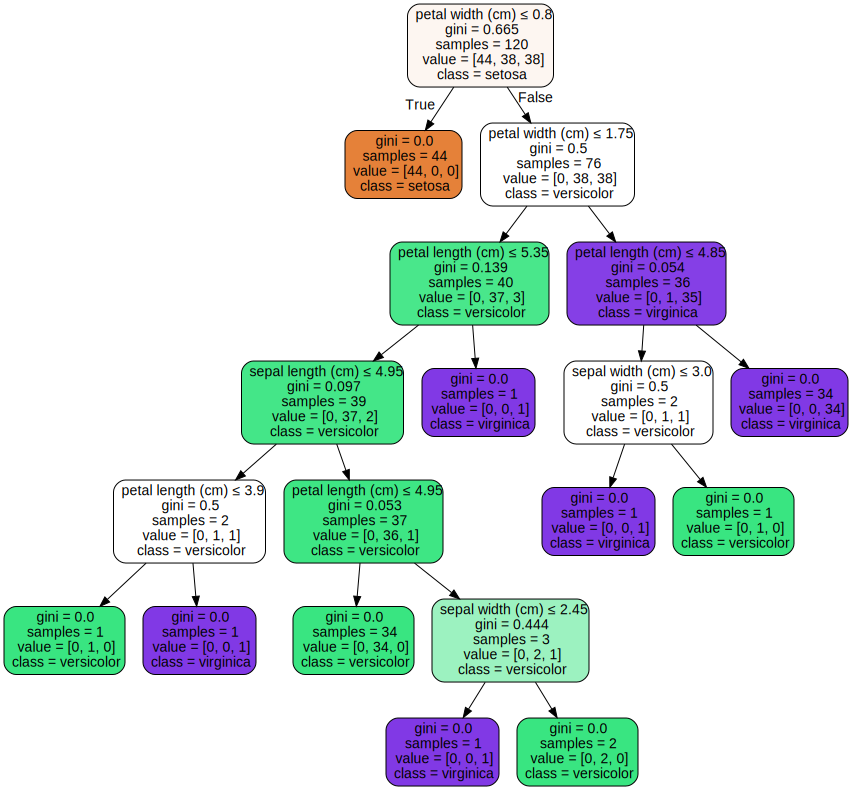

In [4]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    dt_clf,
    out_file=None,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph

##**4) 테스트 데이터로 예측 정확도 구하기**

In [5]:
from sklearn.metrics import accuracy_score

pred = dt_clf.predict(X_test)
accuracy= accuracy_score(y_test, pred)

print('결정 트리 예측 정확도 : {0:.4f}'.format(accuracy))

결정 트리 예측 정확도 : 0.9667


##**5) GridSearchCV를 이용한 하이퍼파라미터 튜닝하기**

In [6]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10]
}

dt = DecisionTreeClassifier(random_state=423)

grid = GridSearchCV(dt, params, cv=3)
grid.fit(X_train, y_train)

print("최적 파라미터:", grid.best_params_
      )
print("최고 정확도:", grid.best_score_
      )

최적 파라미터: {'max_depth': 3, 'min_samples_split': 2}
최고 정확도: 0.9499999999999998


##**6) 최적 모델 평가하기**

In [7]:
best_dt_clf = grid.best_estimator_

pred = best_dt_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print("최종 정확도:", accuracy)

최종 정확도: 0.9333333333333333


##**7) Feature Importance 시각화**

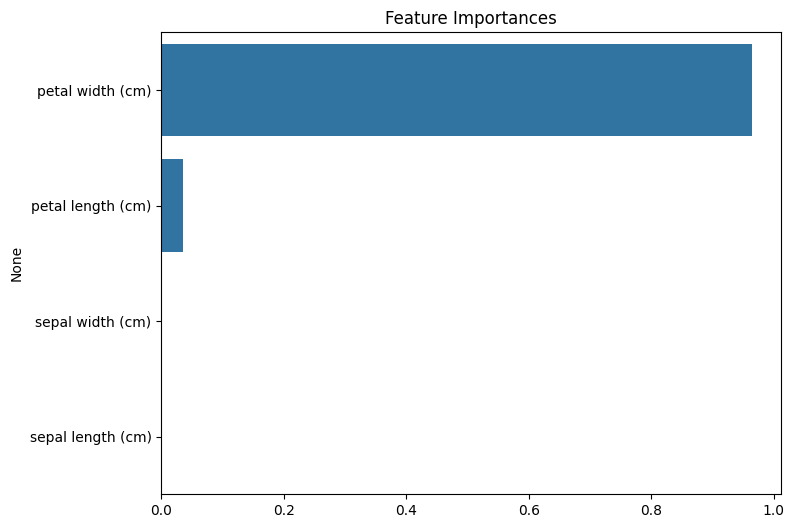

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ftr_importances_values = best_dt_clf.feature_importances_

ftr_importances = pd.Series(
    ftr_importances_values,
    index=iris.feature_names
    )

ftr_top = ftr_importances.sort_values(ascending=False)

plt.figure(figsize=(8,6))
plt.title('Feature Importances')

sns.barplot(
    x=ftr_top.values,
    y=ftr_top.index
    )

plt.show()

1. 'wine' 데이터셋을 불러온 후 훈련/테스트 세트를 분리해주세요.

In [9]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

wine = load_wine()
X_wine = wine.data
y_wine = wine.target

X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(X_wine, y_wine, test_size=0.05, random_state=42)

2. 로지스틱 회귀와 KNN을 개별 모델로 선언한 후 하드 보팅 방식으로 결합해주세요.

로지스틱 회귀: solver='liblinear'로 설정

KNN: n_neighbors=10로 설정

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

lr_clf = LogisticRegression(solver='liblinear', random_state=42)
knn_clf = KNeighborsClassifier(n_neighbors=10)

vo_clf = VotingClassifier(estimators=[('lr', lr_clf), ('knn', knn_clf)], voting='hard')

3-1. 앞서 선언한 로지스틱 회귀와 KNN 모델을 리스트에 담아 for문으로 학습 및 예측해주세요.

3-2. 각 모델의 정확도를 출력해주세요.

In [11]:
from sklearn.metrics import accuracy_score

classifiers = [lr_clf, knn_clf]
for classifier in classifiers:
    classifier.fit(X_train_wine, y_train_wine)
    pred = classifier.predict(X_test_wine)
    accuracy = accuracy_score(y_test_wine, pred)
    name = classifier.__class__.__name__
    print(f'{name} 예측 정확도: {accuracy:.4f}')

LogisticRegression 예측 정확도: 1.0000
KNeighborsClassifier 예측 정확도: 0.6667


4. 2번에서 생성한 보팅 분류기를 학습시킨 후 예측 평가해주세요.

In [12]:
vo_clf.fit(X_train_wine, y_train_wine)
pred_vo = vo_clf.predict(X_test_wine)
accuracy_vo = accuracy_score(y_test_wine, pred_vo)
print(f'보팅 분류기 예측 정확도: {accuracy_vo:.4f}')

보팅 분류기 예측 정확도: 1.0000


5. 결정 트리를 기반으로 하는 배깅 분류기를 생성하고 학습시켜 주세요.

결정 트리 분류기: 600개

무작위 선택 샘플 수: 200개

중복 샘플링 허용, 모든 코어 사용

In [37]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=600,
    max_samples=100,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)
bagging_clf.fit(X_train_wine, y_train_wine)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  max_samples=100, n_estimators=600, n_jobs=-1, oob_score=True,
                  random_state=42)

6. obb 평가를 수행하고 점수를 확인해 주세요.

In [38]:
print(f'OOB 예측 정확도: {bagging_clf.oob_score_:.4f}')

OOB 예측 정확도: 0.9704


7. 학습된 배깅 분류기를 이용해 테스트 데이터에 대한 예측을 수행하고 정확도를 평가해 주세요.

In [39]:
from sklearn.metrics import accuracy_score

pred_bagging = bagging_clf.predict(X_test_wine)

accuracy_bagging = accuracy_score(y_test_wine, pred_bagging)
print(f'배깅 분류기 예측 정확도: {accuracy_bagging:.4f}')

배깅 분류기 예측 정확도: 1.0000


# 4-4. Randomforest

- 다음은 classification에 관한 문제이다. 이용하는 데이터의 이름은 “classification_data”이다. 데이터의 dimension은 (4521, 17)으로 이는 4521개의 observation이있으며 1개의 target column과 16개의 feature column으로 구성되었음을 의미한다. 이 데이터는 bank diposit에 관한 데이터로 보증금 대출가능 여부에 대한 정보를 담고 있다. Target column은 y이며 보증금 대출이 가능한 경우 “yes”, 불가능한 경우 “no”로 표기되어 있다.

- random seed 설정에 유의할 것.

(a) 데이터를 불러온 후 처음 4줄을 출력하시오.

In [40]:
import pandas as pd

df_classification = pd.read_csv('classification_data.csv')
print(df_classification.head(4))

  age;"job";"marital";"education";"default";"balance";"housing";"loan";"contact";"day";"month";"duration";"campaign";"pdays";"previous";"poutcome";"y"
0  30;"unemployed";"married";"primary";"no";1787;...                                                                                                  
1  33;"services";"married";"secondary";"no";4789;...                                                                                                  
2  35;"management";"single";"tertiary";"no";1350;...                                                                                                  
3  30;"management";"married";"tertiary";"no";1476...                                                                                                  


(b) 필요한 변수에 대하여 one-hot encoding과 label encoding을 하시오.



hint)

 label encoding : 'default', 'housing', 'loan', 'y'

 one-hot encoding : 'job', 'marital', 'education', 'contact','month', 'poutcome'

In [41]:
from sklearn.preprocessing import LabelEncoder

df_classification.columns = df_classification.columns.str.replace('"', '')

df_classification = pd.read_csv('classification_data.csv', sep=';')

label_cols = ['default', 'housing', 'loan', 'y']
for col in label_cols:
    le = LabelEncoder()
    df_classification[col] = le.fit_transform(df_classification[col])

one_hot_cols = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
df_classification = pd.get_dummies(df_classification, columns=one_hot_cols, drop_first=True)

(c) Data를 X(feature), y(target)으로 분리하시오.

In [42]:
X = df_classification.drop('y', axis=1)
y = df_classification['y']

(d) Data를 train/test로 split 하시오. (train:test = 3:1, random_seed = 777)

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=777)

(e) Random Forest에 대하여 model fitting 하시오.

    - max_depth = 3, n_estimators = 200, learning_rate = 0.1, random_state = 777

In [44]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(max_depth=3, n_estimators=200, random_state=777)
rf_clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, n_estimators=200, random_state=777)

(f) (e)의 결과에 대하여 confution matrix를 구하시오.

In [45]:
from sklearn.metrics import confusion_matrix

y_pred = rf_clf.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", conf_matrix)

Confusion Matrix:
 [[1014    0]
 [ 117    0]]


# 서포트 벡터 머신(SVM)

가우시안 RBF 커널을 사용하여 gamma 값이 2이고, 하이퍼파라미터 C의 값이 0.005인 SVM 분류기를 만드시오.

In [46]:
from sklearn.svm import SVC

svm_clf = SVC(kernel='rbf', gamma=2, C=0.005, random_state=777)

print(svm_clf)

SVC(C=0.005, gamma=2, random_state=777)
